# Alzheimer’s Disease Prediction Using Logistic Regression and Random Forest Models

## Objective
The goal of this project is to build and compare two machine learning models to predict Alzheimer’s diagnosis.

We first evaluate a baseline model using lifestyle features, and then extend the model by incorporating clinical and demographic data.

This project demonstrates how incorporating clinical data significantly improves predictive performance. Additionally, the Random Forest model outperformed logistic regression, suggesting that non-linear models may better capture complex relationships in the data.

## Approach
We compare:
- A baseline model using lifestyle features only  
- A full model using all available features  

Model performance is evaluated using classification metrics and ROC-AUC.

## Setup and Libraries

The following libraries are used for data handling, visualization, model training, preprocessing, and evaluation.

In [34]:
# Data handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Model selection
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)

## Data Loading

The dataset is loaded and prepared for analysis.

In [35]:
#load Alzheimers dataset
df = pd.read_csv("C:\\Users\\rp090\\OneDrive\\Desktop\\Python Projects\\EDA_Alzheimers\\archive\\alzheimers_disease_data.csv")
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


## Data Overview

The dataset contains demographic, lifestyle, and clinical information for patients.

The target variable is:
- **Diagnosis** (0 = No Alzheimer’s, 1 = Alzheimer’s)

We first inspect the structure of the dataset and check for missing values.

In [36]:
# Inspect dataset structure and data types
df.info()

# View summary statistics of numerical features
df.describe()

# Check class distribution of Alzheimer's diagnosis
df["Diagnosis"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

Diagnosis
0    1389
1     760
Name: count, dtype: int64

## Baseline Model: Lifestyle Features Only

We first evaluate a baseline model using lifestyle-related features to determine how well they predict Alzheimer’s diagnosis on their own.

In [37]:
# Define target variable
y = df["Diagnosis"]

# Define lifestyle features
lifestyle_features = [
    "BMI",
    "EducationLevel",
    "Smoking",
    "AlcoholConsumption",
    "DietQuality",
]

X_lifestyle = df[lifestyle_features]

# Preview selected features and target
print(X_lifestyle.head())
print(y.head())

# Check for missing values in selected features
print(X_lifestyle.isnull().sum())

# Inspect data types of selected features
print(X_lifestyle.dtypes)

         BMI  EducationLevel  Smoking  AlcoholConsumption  DietQuality
0  22.927749               2        0           13.297218     1.347214
1  26.827681               0        0            4.542524     0.518767
2  17.795882               1        0           19.555085     1.826335
3  33.800817               1        1           12.209266     7.435604
4  20.716974               0        0           18.454356     0.795498
0    0
1    0
2    0
3    0
4    0
Name: Diagnosis, dtype: int64
BMI                   0
EducationLevel        0
Smoking               0
AlcoholConsumption    0
DietQuality           0
dtype: int64
BMI                   float64
EducationLevel          int64
Smoking                 int64
AlcoholConsumption    float64
DietQuality           float64
dtype: object


### Train-Test Split

The dataset is split into training and validation sets to evaluate model performance on unseen data.

In [38]:
# Split data into training and validation sets (80/20 split)
X_train_life, X_val_life, y_train_life, y_val_life = train_test_split(
    X_lifestyle,
    y,
    test_size=0.2,
    random_state=1
)

# Check split dimensions
print(X_train_life.shape)
print(X_val_life.shape)

(1719, 5)
(430, 5)


### Logistic Regression (Baseline)

We train a logistic regression model using lifestyle features only. Class weighting is applied to address class imbalance.

In [39]:
# Train Logistic Regression model
log_model_life = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_model_life.fit(X_train_life, y_train_life)

# Predictions
log_preds_life = log_model_life.predict(X_val_life)

# Evaluation
print(classification_report(y_val_life, log_preds_life))
print(confusion_matrix(y_val_life, log_preds_life))

              precision    recall  f1-score   support

           0       0.66      0.53      0.59       277
           1       0.38      0.51      0.43       153

    accuracy                           0.53       430
   macro avg       0.52      0.52      0.51       430
weighted avg       0.56      0.53      0.54       430

[[148 129]
 [ 75  78]]


### Random Forest (Baseline)

We train a Random Forest model using the same lifestyle features to compare performance with a non-linear model.

In [40]:
# Train Random Forest model
rf_model_life = RandomForestClassifier(
    random_state=1,
    class_weight='balanced'
)

rf_model_life.fit(X_train_life, y_train_life)

# Predictions
rf_preds_life = rf_model_life.predict(X_val_life)

# Evaluate model performance
print(classification_report(y_val_life, rf_preds_life))
print(confusion_matrix(y_val_life, rf_preds_life))

              precision    recall  f1-score   support

           0       0.63      0.84      0.72       277
           1       0.30      0.12      0.18       153

    accuracy                           0.58       430
   macro avg       0.47      0.48      0.45       430
weighted avg       0.51      0.58      0.53       430

[[232  45]
 [134  19]]


### Baseline ROC Comparison

The ROC curves below compare the performance of the baseline logistic regression and Random Forest models using lifestyle features only.

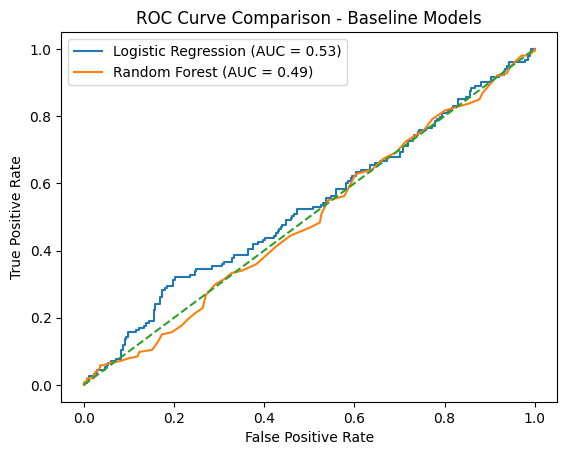

In [41]:
# Logistic Regression probabilities
y_probs_log_life = log_model_life.predict_proba(X_val_life)[:, 1]
fpr_log_life, tpr_log_life, _ = roc_curve(y_val_life, y_probs_log_life)
roc_auc_log_life = auc(fpr_log_life, tpr_log_life)

# Random Forest probabilities
y_probs_rf_life = rf_model_life.predict_proba(X_val_life)[:, 1]
fpr_rf_life, tpr_rf_life, _ = roc_curve(y_val_life, y_probs_rf_life)
roc_auc_rf_life = auc(fpr_rf_life, tpr_rf_life)

# Plot both ROC curves
plt.figure()

plt.plot(fpr_log_life, tpr_log_life, label=f"Logistic Regression (AUC = {roc_auc_log_life:.2f})")
plt.plot(fpr_rf_life, tpr_rf_life, label=f"Random Forest (AUC = {roc_auc_rf_life:.2f})")

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Baseline Models")
plt.legend()
plt.show()

The ROC curves show that both models have limited performance when using lifestyle features alone. While Random Forest may perform better in classification metrics, logistic regression can still provide competitive probability ranking as reflected in the AUC.

## Full Feature Model

After establishing a baseline with lifestyle features only, we expand the feature set to include clinical and demographic variables.

This allows us to evaluate whether a broader set of patient information improves predictive performance.

In [42]:
# Define full feature set (exclude target and non-numeric identifier)
X_all = df.drop(["Diagnosis", "DoctorInCharge"], axis=1)
y_all = df["Diagnosis"]

# Preview selected features
print(X_all.head())

# Check for missing values
print(X_all.isnull().sum())

# Inspect data types
print(X_all.dtypes)

   PatientID  Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0       4751   73       0          0               2  22.927749        0   
1       4752   89       0          0               0  26.827681        0   
2       4753   73       0          3               1  17.795882        0   
3       4754   74       1          0               1  33.800817        1   
4       4755   89       0          0               0  20.716974        0   

   AlcoholConsumption  PhysicalActivity  DietQuality  ...       MMSE  \
0           13.297218          6.327112     1.347214  ...  21.463532   
1            4.542524          7.619885     0.518767  ...  20.613267   
2           19.555085          7.844988     1.826335  ...   7.356249   
3           12.209266          8.428001     7.435604  ...  13.991127   
4           18.454356          6.310461     0.795498  ...  13.517609   

   FunctionalAssessment  MemoryComplaints  BehavioralProblems       ADL  \
0              6.518877            

### Train-Test Split

The full feature dataset is split into training and validation sets to evaluate model performance on unseen data.

In [43]:
# Split data into training and validation sets
X_train_all, X_val_all, y_train_all, y_val_all = train_test_split(
    X_all,
    y_all, 
    test_size = 0.2,
    random_state = 1
)

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_all)
X_val_scaled = scaler.transform(X_val_all)

#Check split data
print(X_train_all.shape)
print(y_train_all.shape)

(1719, 33)
(1719,)


### Logistic Regression (Full Features)

We train a logistic regression model using the full feature set. Feature scaling is applied to improve model stability, and class weighting is used to address class imbalance.

In [44]:
#Train full-feature logistic regression model
log_model_all = LogisticRegression(
    random_state = 1,
    max_iter = 3000,
    class_weight = 'balanced',
    solver = 'liblinear'
)

log_model_all.fit(X_train_scaled, y_train_all)

#Run model predictions and evaluate
log_preds_all = log_model_all.predict(X_val_scaled)
print(classification_report(y_val_all, log_preds_all))
print(confusion_matrix(y_val_all, log_preds_all))



              precision    recall  f1-score   support

           0       0.88      0.82      0.85       277
           1       0.71      0.80      0.75       153

    accuracy                           0.81       430
   macro avg       0.79      0.81      0.80       430
weighted avg       0.82      0.81      0.81       430

[[226  51]
 [ 30 123]]


## Feature Importance

We examine the coefficients of the logistic regression model to understand which features contribute most to predicting Alzheimer’s diagnosis.

Positive coefficients indicate a higher likelihood of Alzheimer’s, while negative coefficients indicate a lower likelihood.

FunctionalAssessment   -1.262882
ADL                    -1.212767
MemoryComplaints        1.061174
BehavioralProblems      0.934214
MMSE                   -0.841390
PatientID               0.204137
CholesterolHDL          0.159813
CholesterolLDL         -0.148791
SleepQuality           -0.121796
Smoking                -0.116361
dtype: float64


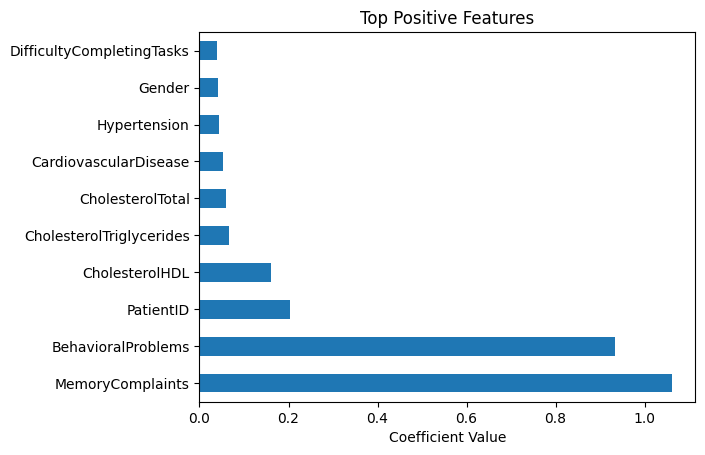

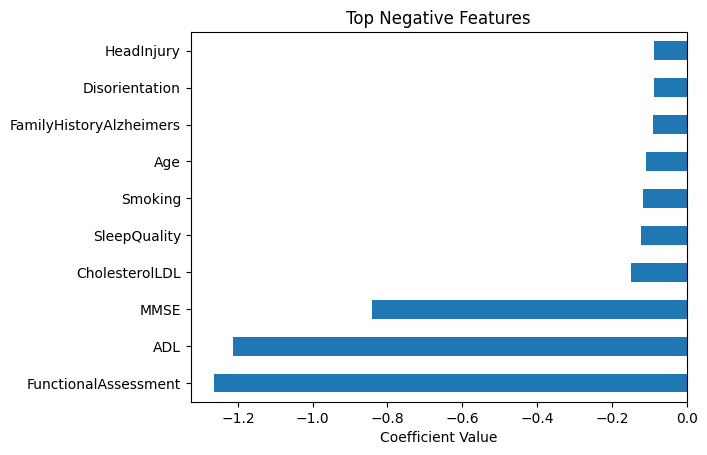

In [45]:
# Feature importance (logistic regression coefficients)
coefficients = pd.Series(
    log_model_all.coef_[0],
    index=X_train_all.columns
)

# Sort by magnitude
coefficients = coefficients.sort_values(key=abs, ascending=False)

print(coefficients.head(10))

# Separate positive and negative features
positive = coefficients[coefficients > 0].sort_values(ascending=False)
negative = coefficients[coefficients < 0].sort_values()

# Plot positive features
plt.figure()
positive.head(10).plot(kind='barh')
plt.title("Top Positive Features")
plt.xlabel("Coefficient Value")
plt.show()

# Plot negative features
plt.figure()
negative.head(10).plot(kind='barh')
plt.title("Top Negative Features")
plt.xlabel("Coefficient Value")
plt.show()

Some features show a negative coefficient despite being positively associated with Alzheimer's. This was due to multicollinearity between highly correlated coginitive symptom variables, causing the model to distribute importance across overlapping predictors. 

## Regularization Tuning

We test different values of the regularization parameter `C` to see how model performance changes.

Smaller values of `C` apply stronger regularization, which can reduce overfitting but may also lead to underfitting if the model becomes too constrained.

### Logistic Regression with Moderate Regularization (`C = 0.1`)

We first test a moderately stronger regularization setting to determine whether it improves generalization.

In [46]:
# Train regularized logistic regression model (C = 0.1)
log_model_c01 = LogisticRegression(
    class_weight='balanced',
    solver='liblinear',
    max_iter=3000,
    C=0.1,
    random_state=42
)

log_model_c01.fit(X_train_scaled, y_train_all)

# Run model predictions and evaluate
log_preds_c01 = log_model_c01.predict(X_val_scaled)
print(classification_report(y_val_all, log_preds_c01))
print(confusion_matrix(y_val_all, log_preds_c01))

# Inspect coefficient importance
regularized_importance_c01 = pd.Series(
    log_model_c01.coef_[0],
    index=X_train_all.columns
).sort_values(key=abs, ascending=False)

              precision    recall  f1-score   support

           0       0.88      0.81      0.85       277
           1       0.70      0.80      0.75       153

    accuracy                           0.81       430
   macro avg       0.79      0.81      0.80       430
weighted avg       0.82      0.81      0.81       430

[[225  52]
 [ 30 123]]


### Logistic Regression with Strong Regularization (`C = 0.01`)

We then test a smaller value of `C` to observe whether stronger regularization improves performance or causes underfitting.

              precision    recall  f1-score   support

           0       0.91      0.80      0.85       277
           1       0.70      0.85      0.77       153

    accuracy                           0.82       430
   macro avg       0.80      0.82      0.81       430
weighted avg       0.83      0.82      0.82       430

[[221  56]
 [ 23 130]]


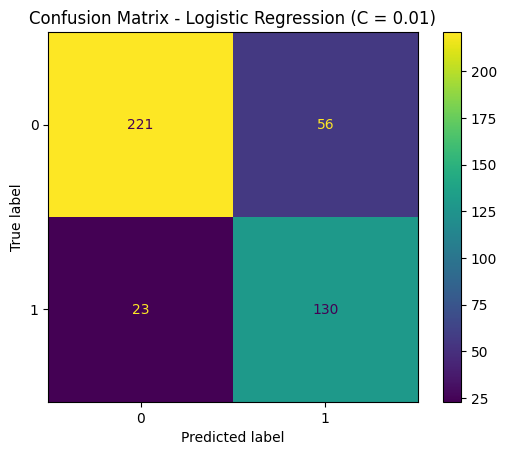

In [47]:
# Train regularized logistic regression model (C = 0.01)
log_model_c001 = LogisticRegression(
    class_weight='balanced',
    solver='liblinear',
    max_iter=3000,
    C=0.01,
    random_state=42
)

log_model_c001.fit(X_train_scaled, y_train_all)

# Run model predictions and evaluate
log_preds_c001 = log_model_c001.predict(X_val_scaled)
print(classification_report(y_val_all, log_preds_c001))
print(confusion_matrix(y_val_all, log_preds_c001))

#Plot confusion matrix
cm_disp = ConfusionMatrixDisplay(confusion_matrix(y_val_all, log_preds_c001))
cm_disp.plot()

plt.title("Confusion Matrix - Logistic Regression (C = 0.01)")

#Save plot
plt.savefig('confusion_matrix.png', bbox_inches = 'tight')
plt.show()

# Inspect coefficient importance
regularized_importance_c001 = pd.Series(
    log_model_c001.coef_[0],
    index=X_train_all.columns
).sort_values(key=abs, ascending=False)

### Tuning Summary

Stronger regularization (`C = 0.01`) improved model performance across multiple metrics, including recall, F1-score, and accuracy.

In particular, the model achieved higher recall for Alzheimer’s cases and reduced the number of false negatives, which is critical in a medical context.

This suggests that a simpler model generalizes better to unseen data, and `C = 0.01` was selected as the final regularization setting.

## Final ROC Curve

We evaluate the final logistic regression model (`C = 0.01`) using the ROC curve and compute the AUC score.

This provides a threshold-independent measure of model performance.

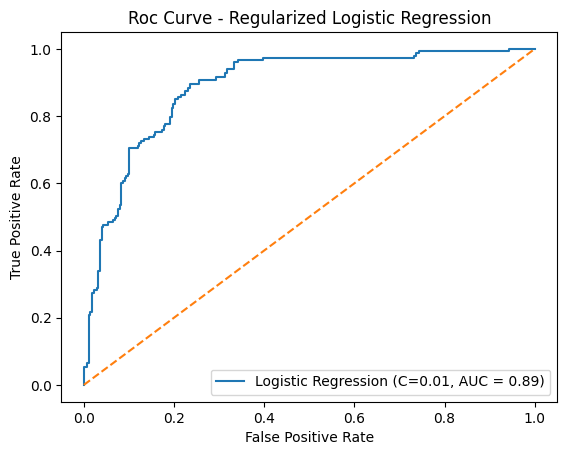

In [48]:
#Generate probabilities, not predictions
y_probs_regularized = log_model_c001.predict_proba(X_val_scaled)[:, 1]

#Compute ROC
fpr_regularized, tpr_regularized, thresholds_regularized = roc_curve(y_val_all, y_probs_regularized)
roc_auc_final = auc(fpr_regularized, tpr_regularized)

#Plot ROC curve
plt.figure()
plt.plot(fpr_regularized, tpr_regularized, label=f"Logistic Regression (C=0.01, AUC = {roc_auc_final:.2f})")
plt.plot([0,1], [0,1], linestyle = '--') #random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Roc Curve - Regularized Logistic Regression")
plt.legend()
plt.savefig('ROC_Curve.png', bbox_inches = 'tight')
plt.show()

## Results Summary

- The baseline models using lifestyle features alone showed limited predictive performance.  
- Incorporating clinical and cognitive features significantly improved predictive performance compared to lifestyle features alone.

Final Logistic Regression Model (`C = 0.01`):
- Accuracy: ~0.82  
- Recall (Alzheimer’s): ~0.85  
- AUC: ~0.86  

The Random Forest model also performed well, but logistic regression with regularization provided strong and consistent performance across evaluation metrics.

## Conclusion

This project demonstrates that:

- Clinical and cognitive features significantly improve Alzheimer’s prediction compared to lifestyle features alone.  
- Regularization plays an important role in improving model generalization.  
- Logistic regression, when properly tuned, provides a strong and interpretable model for this task.  

While the Random Forest model achieved strong classification performance, logistic regression with regularization (`C = 0.01`) was selected as the final model due to its interpretability and consistent performance across evaluation metrics. Overall, combining appropriate feature selection with model tuning leads to meaningful improvements in predictive performance. 

## Future Improvements

- Perform more extensive hyperparameter tuning  
- Explore additional models such as Gradient Boosting or XGBoost  
- Apply cross-validation for more robust evaluation  
- Investigate feature interactions and reduce multicollinearity  